## Import

In [1]:
import torch
import seaborn as sns
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid

import matplotlib.colors as mcolors

from sde_routines_scalar_reg import *
from utils import BimodalGaussianMixture, l1l2_sampler, generate_signed_exponential, kl_divergence, entropy, histedges_equalN, gen_unbalanced, bimodal

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

c1='blue'
c2='red'

def colorFader(c1,c2,mix=0):
    c1=np.array(mpl.colors.to_rgb(c1))
    c2=np.array(mpl.colors.to_rgb(c2))
    return mpl.colors.to_hex((1-mix)*c1 + mix*c2)

# Parameters
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Data generation

In [48]:
n1 = int(1e5)
n_steps = 10000

beta = 1.7

x1 = torch.from_numpy(bimodal(n1,beta)).cuda()

#x1 = gen_unbalanced(n1, n_steps, beta, device='cuda')
#x1 = torch.load('data/1e6_beta_15.pt').cuda()

Constante de normalisation Z ≈ 73064.6751


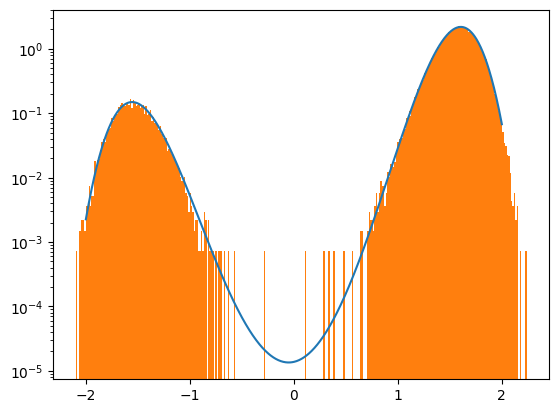

In [49]:
def U(x, beta):
    return -(-beta * x**4 + 5 * beta * x**2 +  0.5*beta * x)#beta*(.5*x**2-np.abs(x)+x/8)

beta = beta

x_space = np.linspace(-2,2,1000)

plt.plot(x_space, 250*np.exp(-U(x_space, beta))/np.exp(-U(x_space, beta)).sum())
plt.hist(x1.cpu(), density=True, bins='sqrt')

plt.yscale('log')

plt.show()

## Sampling

In [50]:
xt_to_save = {}

In [51]:
potential_names = ['x', 'x2', 'x3', 'x4']

nt = n_steps
t = torch.linspace(0, 1, nt + 1)

sigma = 10 # 1000 pour 3

In [52]:
n1 = n1

beta = beta

x1 = torch.from_numpy(bimodal(n1,beta)).cuda()#torch.randn(n1).cuda()*.5#torch.from_numpy(bimodal(n1,beta)).cuda()

# regularisation 
lam = 1e-6
n_subsample = 10

Constante de normalisation Z ≈ 73064.6751


In [53]:
x0, xt, barphi_e, barphi_p, eta_t, eta_t2, dH_t_bound, Theta_reg = solve_sde(x1, n1, t, [sigma for i in range(nt+1)],
                                                                  potential_names=potential_names, device=device, std_init=1, 
                                                                             lam=lam, n_subsample=n_subsample, regularization=0.0, reg_eps=1e-8) #'x', 'x_abs', 'x2'

Step 0/10000
Step 200/10000
Step 400/10000
Step 600/10000
Step 800/10000
Step 1000/10000
Step 1200/10000
Step 1400/10000
Step 1600/10000
Step 1800/10000
Step 2000/10000
Step 2200/10000
Step 2400/10000
Step 2600/10000
Step 2800/10000
Step 3000/10000
Step 3200/10000
Step 3400/10000
Step 3600/10000
Step 3800/10000
Step 4000/10000
Step 4200/10000
Step 4400/10000
Step 4600/10000
Step 4800/10000
Step 5000/10000
Step 5200/10000
Step 5400/10000
Step 5600/10000
Step 5800/10000
Step 6000/10000
Step 6200/10000
Step 6400/10000
Step 6600/10000
Step 6800/10000
Step 7000/10000
Step 7200/10000
Step 7400/10000
Step 7600/10000
Step 7800/10000
Step 8000/10000
Step 8200/10000
Step 8400/10000
Step 8600/10000
Step 8800/10000
Step 9000/10000
Step 9200/10000
Step 9400/10000
Step 9600/10000
Step 9800/10000


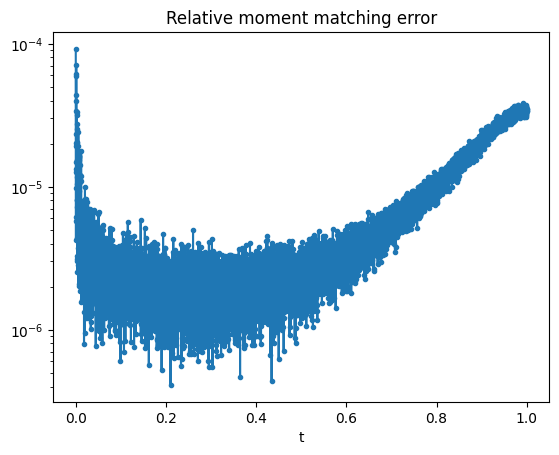

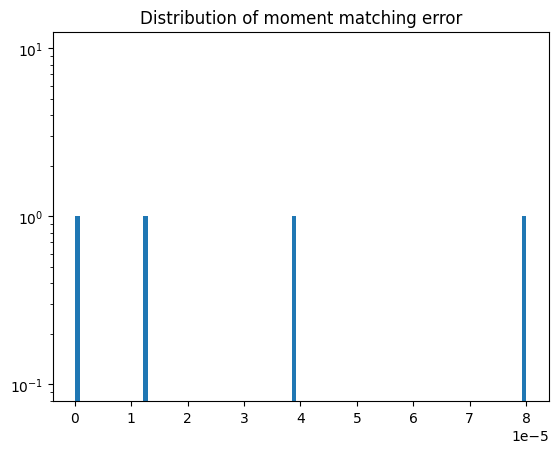

In [54]:
plot_moment_matching(barphi_e, barphi_p, t, threshold=1e-5) 

SDE interpolation complete!


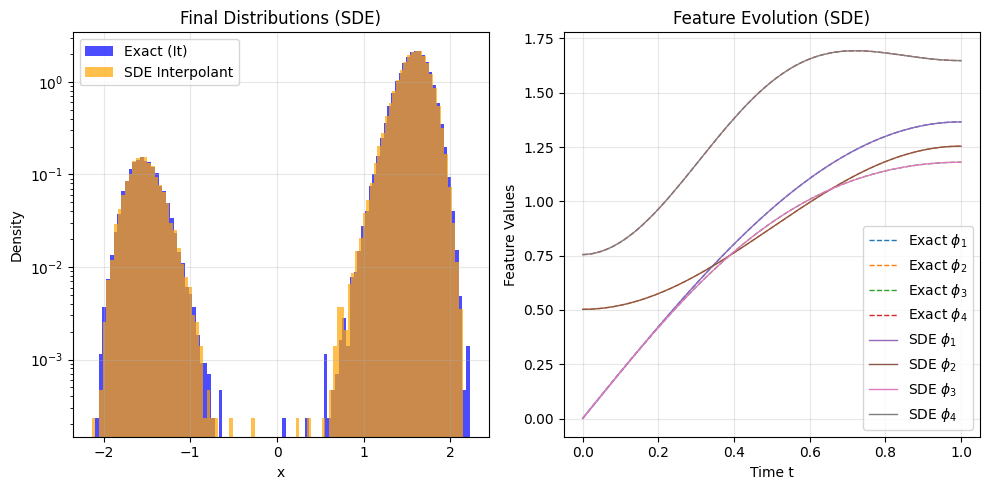


Final Results:
Final feature error: 0.000141
Max feature error during interpolation: 0.000166

Distribution Statistics:
Target (x1) - Mean: 1.3660, Std: 0.8016
Initial (x0) - Mean: 0.0007, Std: 1.0027
Final SDE interpolant - Mean: 1.3660, Std: 0.8016


In [55]:
_ = plot_SD_results(x0, x1, xt, barphi_e, barphi_p, t, sigma, nt, potential_names)

### Analysis of $\theta$

Monomial potentials are defined as $x^k/k$, so the computed $\theta$ need to be renormalized.

[ 0.85  8.5   0.   -1.7 ]
10000 998


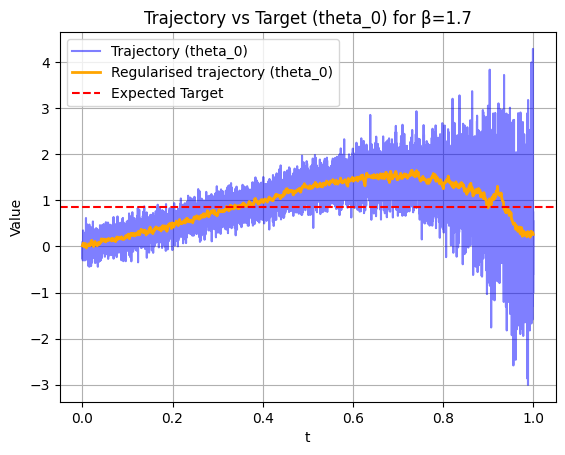

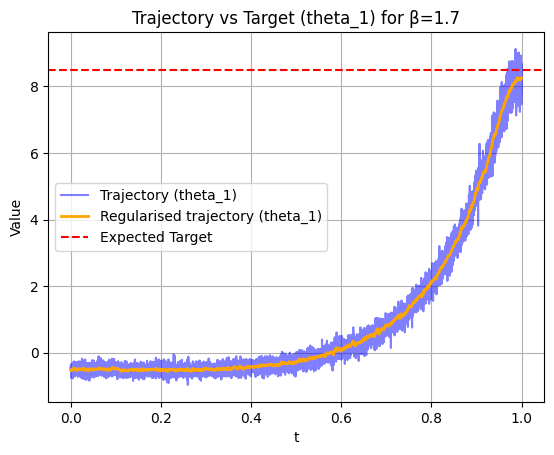

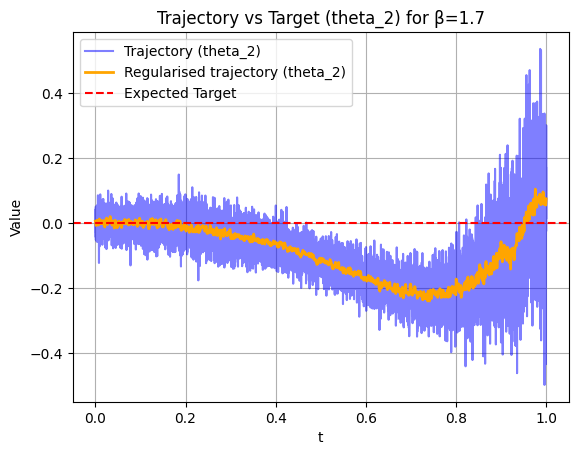

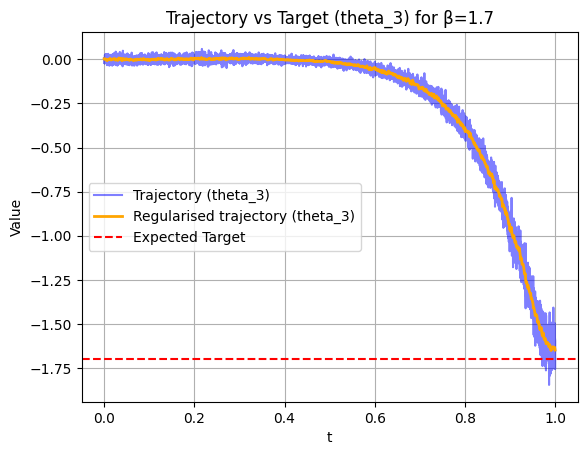

In [56]:
expected_theta = np.array([beta/2, 5*beta, 0, -beta])
print(expected_theta) 

# 2. Convert your trajectory tensor to a numpy array
# Assumes eta_t2 shape is (num_time_steps, 4)
traj_data = eta_t2.numpy() / torch.Tensor([1,2,3,4])
traj_reg = Theta_reg / torch.Tensor([1,2,3,4])

# 3. Create the time axis based on the number of steps in your trajectory
len_t = traj_data.shape[0]
len_reg = traj_reg.shape[0]
print(len_t, len_reg) 

# 4. Plot each of the 4 coordinates
labels = ["theta_0", "theta_1", "theta_2", "theta_3"] # Adjust if you have custom labels

for i in range(4):
    plt.figure()

    x_t = np.linspace(0, 1, len_t)
    x_reg = np.linspace(0, 1, len_reg)
    
    # Plot the actual trajectory over time
    plt.plot(x_t, traj_data[:, i], label=f"Trajectory ({labels[i]})", color="blue", alpha=0.5)
    plt.plot(x_reg, traj_reg[:,i], label=f"Regularised trajectory ({labels[i]})", lw=2, color="orange") 
    
    # Plot the flat expected theoretical target
    plt.axhline(expected_theta[i], linestyle='--', color='red', label="Expected Target")
    
    plt.title(f"Trajectory vs Target ({labels[i]}) for β={beta}")
    plt.xlabel("t")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True)
    plt.show()

In [57]:
print('Target theta:', str(torch.Tensor([beta/2, 5*beta, 0, -beta])))
print('Estimated theta at t=1:', str(eta_t2[-1]/torch.Tensor([1,2,3,4])))
print('Estimated regularised theta at t=1:', str(Theta_reg[-1]/torch.Tensor([1,2,3,4])))
print('Estimated theta averaged on the 10 last steps:', str(eta_t2[-10:].mean(0)/torch.Tensor([1,2,3,4])))

Target theta: tensor([ 0.8500,  8.5000,  0.0000, -1.7000])
Estimated theta at t=1: tensor([ 0.7392,  7.9383,  0.0153, -1.5895])
Estimated regularised theta at t=1: tensor([ 0.2623,  8.2547,  0.0740, -1.6483])
Estimated theta averaged on the 10 last steps: tensor([ 0.6766,  8.1505,  0.0200, -1.6281])


## KL divergence 

In [58]:
# ----------------------------------------------------------------------
# KL Divergence Computation Cell
# ----------------------------------------------------------------------
from scipy.integrate import simpson

# 1. Define basis functions and log-density helpers matching kl_divergence_analysis.py
def log_p_unnorm(x, theta):
    return theta[0] * x + theta[1] * (x**2 / 2) + theta[2] * (x**3 / 3) + theta[3] * (x**4 / 4)

def log_Z(theta, x_range=(-50.0, 50.0), n_grid=4001):
    grid = np.linspace(*x_range, n_grid)
    log_vals = log_p_unnorm(grid, theta)
    m = log_vals.max()
    vals = np.exp(log_vals - m)
    val = simpson(vals, x=grid)
    if val <= 0 or not np.isfinite(val):
        return np.nan
    return m + np.log(val)

# 2. Setup grid and True Density based on your notebook's U(x, beta)
x_range = (-50.0, 50.0)
n_grid = 4001
grid = np.linspace(*x_range, n_grid)

# Compute true log-density using the energy convention U from your notebook
log_p_true_unnorm = -U(grid, beta)
m_true = log_p_true_unnorm.max()
p_true_shifted = np.exp(log_p_true_unnorm - m_true)
log_Z_true = m_true + np.log(simpson(p_true_shifted, x=grid))
log_p_true_grid = log_p_true_unnorm - log_Z_true
p_true_grid = np.exp(log_p_true_grid)

# 3. Extract final theta vectors (ensuring they are numpy arrays in CPU memory)
# Note: Since your plotting loop divides by [1,2,3,4] to match expected_theta,
# the raw eta_t2 and Theta_reg are already in the natural parameter basis.
theta_final_mgd = eta_t2[-1].cpu().numpy() if hasattr(eta_t2[-1], 'cpu') else eta_t2[-1]
theta_final_reg = Theta_reg[-1].cpu().numpy() if hasattr(Theta_reg[-1], 'cpu') else Theta_reg[-1]

# 4. Compute KL Divergence helper function
def compute_kl(theta_target):
    if theta_target[3] >= 0:
        return np.nan
    lZ = log_Z(theta_target, x_range=x_range, n_grid=n_grid)
    if np.isnan(lZ):
        return np.nan
    
    log_pth = log_p_unnorm(grid, theta_target) - lZ
    
    with np.errstate(divide="ignore", invalid="ignore"):
        vals = p_true_grid * (log_p_true_grid - log_pth)
    vals = np.where(p_true_grid > 0, vals, 0.0)  # Enforce 0 * log(0) := 0
    
    return simpson(vals, x=grid)

# 5. Execute and print results
kl_mgd = compute_kl(theta_final_mgd)
kl_reg = compute_kl(theta_final_reg)

print("=== Final KL Divergence Results ===")
print(f"Beta: {beta}")
print(f"MGD Final KL (true || p_theta): {kl_mgd:.6e}")
print(f"REG Final KL (true || p_theta): {kl_reg:.6e}")

=== Final KL Divergence Results ===
Beta: 1.7
MGD Final KL (true || p_theta): 3.073712e-03
REG Final KL (true || p_theta): 7.075274e-02


In [50]:
4/(2*n1) 

4e-05